### 0.1 Table Contents
1. Importing data
2. Visualizing the images
3. Baseline models
4. Visualizing the results
5. Adding a Max Pooling Layer
6. Data Augmentation
7. Improving the model
8. Transfer Learning

### Noteboook Imports

In [1]:
import os 
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras import Sequential, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import layers, models
import tensorflow_hub as hub


I0000 00:00:1776065546.785047   16511 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776065546.832722   16511 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776065548.032727   16511 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### 1. Importing Data

In [2]:
# install kaggle
!pip install kaggle

#saya pakai vs code, jadi lgsg upload kaggle di folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d carlosrunner/pizza-not-pizza


Dataset URL: https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza
License(s): other
pizza-not-pizza.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -o pizza-not-pizza.zip

In [6]:
data_directory = pathlib.Path("pizza_not_pizza")
# mengambil nama kelas
class_names = [item.name for item in data_directory.glob('*')]
print(class_names)
# path masing-masing kelas
pizza_dir = data_directory / "pizza"
not_pizza_dir = data_directory / "not_pizza"


['not_pizza', 'food101_subset.py', 'pizza']


Let us first check how many images we have of a pizza

In [7]:
num_pizza_images = len(os.listdir(pizza_dir))
non_pizza_images = len(os.listdir(not_pizza_dir))
print(f'Number of Pizza images: {num_pizza_images}')
print(f'Number of Non-Pizza images: {non_pizza_images}')


Number of Pizza images: 983
Number of Non-Pizza images: 983


### 2. Visualizing the images

In [8]:
data_gen = ImageDataGenerator(rescale = 1/255., validation_split = 0.2)

train_data = data_gen.flow_from_directory(
    data_directory,
    target_size = (224, 224),
    batch_size = 32,
    subset = 'training',
    class_mode = 'binary')
val_data = data_gen.flow_from_directory(
    data_directory,
    target_size = (224, 224),
    batch_size = 32,
    subset = 'validation',
    class_mode = 'binary')

Found 1574 images belonging to 2 classes.
Found 392 images belonging to 2 classes.


In [9]:
images, labels = next(train_data)
len(images), len(labels), images[0].shape

(32, 32, (224, 224, 3))

In [10]:
def plot_random_images():
    """
    Plots 20 Random Images from the dataset
    """
    images, labels = next(train_data)
    labels = labels.astype('int32')
    i = 1

    plt.figure(figsize = (10, 5))
    
    for image, label in zip(images, labels):
        plt.subplot(4, 5, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == 21:
            break
    plt.tight_layout()
    plt.show()

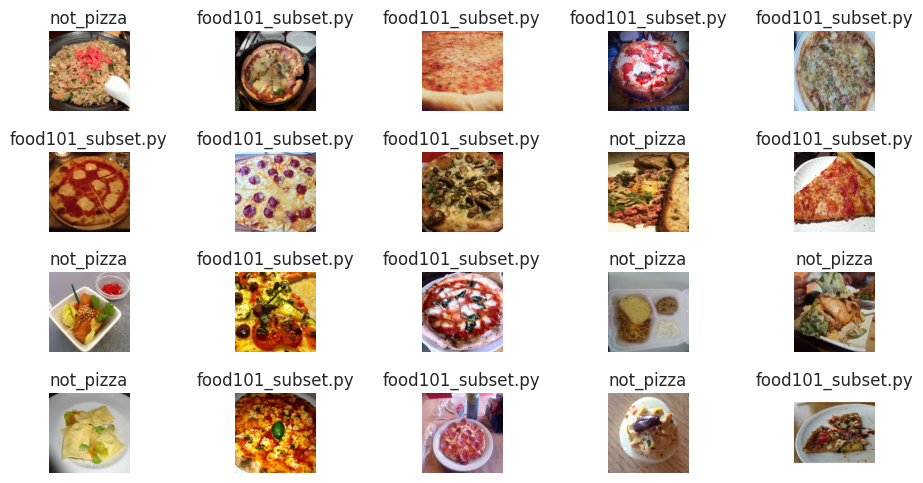

In [11]:
plot_random_images()

### 3. Baseline model
Let Us First create a baseline model without doing data augmentation and not adding a Max Pooling Layer

In [12]:
tf.random.set_seed(42)

model_1 = Sequential([
    Input(shape = (224, 224, 3)), # Input layer
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'), # First C
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'), # Second
    Flatten(),
    Dense(1, activation = 'sigmoid') # Output layer
])
model_1.compile(loss = BinaryCrossentropy(),
                optimizer = Adam(),
                metrics = ['accuracy'])

history_1 = model_1.fit(train_data,
                        epochs= 5,
                        steps_per_epoch = len(train_data),
                        validation_data = val_data,
                        validation_steps = len(val_data))


I0000 00:00:1776065574.695712   16511 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2610 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/5


I0000 00:00:1776065575.651708   16511 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1776065576.379892   16732 service.cc:153] XLA service 0x754324031ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776065576.379912   16732 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650 with Max-Q Design, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776065576.398889   16732 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776065576.598113   16732 cuda_dnn.cc:461] Loaded cuDNN version 92000


 2/50 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.5156 - loss: 1.1534

I0000 00:00:1776065583.246091   16732 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 235ms/step - accuracy: 0.5534 - loss: 2.2074 - val_accuracy: 0.6913 - val_loss: 0.6681
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7154 - loss: 0.5919 - val_accuracy: 0.6684 - val_loss: 0.5998
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8463 - loss: 0.3911 - val_accuracy: 0.6505 - val_loss: 0.6212
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9562 - loss: 0.1627 - val_accuracy: 0.6811 - val_loss: 0.6803
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.9892 - loss: 0.0574 - val_accuracy: 0.7296 - val_loss: 0.6757


### 4. Visualizing the Results

In [13]:
# Plot the validation and training data separately
def plot_loss_curves(history):
    """
    Plots the curves of both loss and accuracy
    """

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(loss))

    fig, ax = plt.subplots(1, 2, figsize = (20, 5))

    # Plotting loss
    ax1 = sns.lineplot(x = epochs, y = loss, label='Training Loss', ax= ax[0])
    ax1 = sns.lineplot(x = epochs, y = val_loss, label='Validation Loss', ax= ax[0])
    ax1.set(title = 'Loss', xlabel = 'Epochs')
    
    # Plot accuracy
    ax2 = sns.lineplot(x = epochs, y = accuracy, label='Training Accuracy', ax= ax[1])
    ax2 = sns.lineplot(x = epochs, y = val_accuracy, label='Validation Accuracy', ax=ax[1])
    ax2.set(title = 'Accuracy', xlabel = 'Epochs')


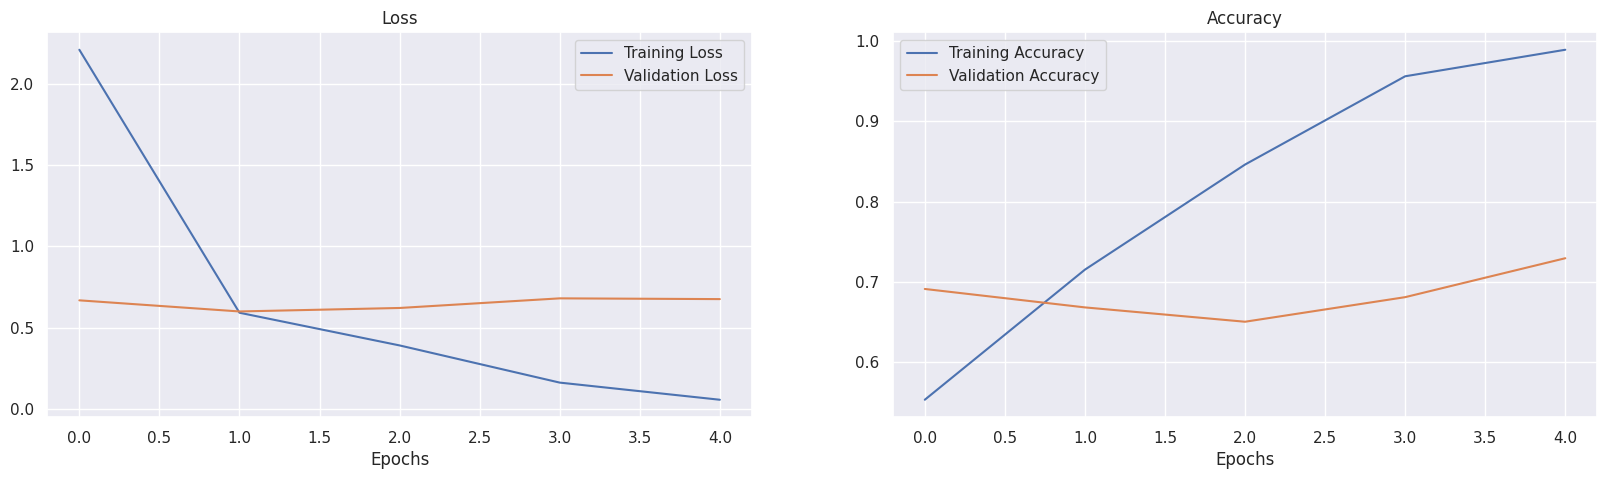

In [14]:
plot_loss_curves(history_1)

### 5. Adding a Max Pooling Layer
Lets add a Max Pooling layer and check whether the accuracy improves

In [15]:
model_2 = Sequential([
    Input(shape = (224, 224, 3)),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2), # It will reduce the number of features by half
    Conv2D(filters = 32, kernel_size =2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')
])
model_2.compile(
    loss = BinaryCrossentropy(),
    optimizer = Adam(),
    metrics = ['accuracy'])

history_2 = model_2.fit(
    train_data,
    epochs= 5,
    steps_per_epoch = len(train_data),
    validation_data = val_data,
    validation_steps = len(val_data))

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.5858 - loss: 0.7281 - val_accuracy: 0.7143 - val_loss: 0.5957
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.7084 - loss: 0.5783 - val_accuracy: 0.7398 - val_loss: 0.5469
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7402 - loss: 0.5209 - val_accuracy: 0.7168 - val_loss: 0.5693
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8164 - loss: 0.4496 - val_accuracy: 0.7372 - val_loss: 0.5428
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8571 - loss: 0.3640 - val_accuracy: 0.7245 - val_loss: 0.6071


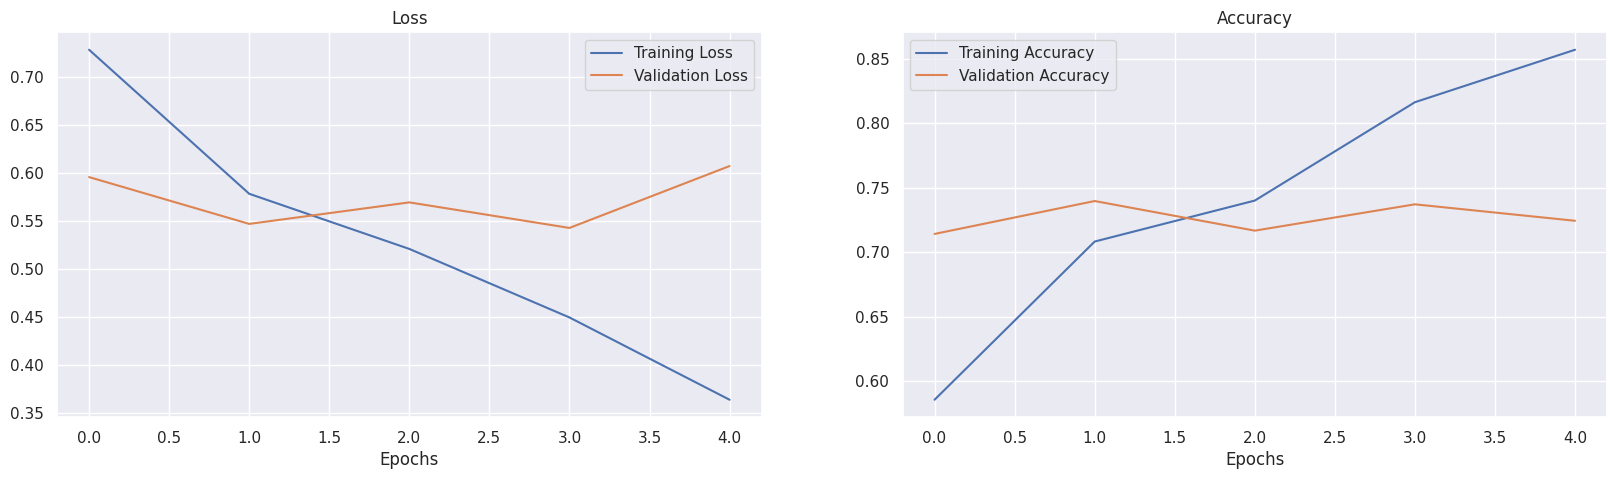

In [16]:
plot_loss_curves(history_2)

We have a maximum validation accuracy of around 75% which is an improvement as compared to our previous model, let
us do data augmentation and see whether it improves the accuracy further

### 6. Data Augmentation

In [17]:
data_gen_augmented = ImageDataGenerator(
    rescale = 1/255.,
    validation_split = 0.2,
    zoom_range = 0.2,
    horizontal_flip= True,
    rotation_range = 20,
    width_shift_range=0.2,
    height_shift_range=0.2)

print('Augmented training Images:')
train_data_augmented = data_gen_augmented.flow_from_directory(
    data_directory,
    target_size = (224, 224),
    batch_size = 32,
    subset = 'training',
    class_mode = 'binary')

print('Unchanged Validation Images:')
val_data = data_gen.flow_from_directory(
    data_directory,
    target_size = (224, 224),
    batch_size = 32,
    subset = 'validation',
    class_mode = 'binary')

Augmented training Images:
Found 1574 images belonging to 2 classes.
Unchanged Validation Images:
Found 392 images belonging to 2 classes.


In [18]:
def plot_random_images_augmented():
    """
    Plots 20 Random Images from the dataset
    """
    
    images_augmented, labels_augmented = next(train_data_augmented)
    labels_augmented = labels_augmented.astype('int32')
    i = 1
    plt.figure(figsize = (10, 5))

    for image, label in zip(images_augmented, labels_augmented):
        plt.subplot(4, 5, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == 21:
            break

    plt.tight_layout()
    plt.show()

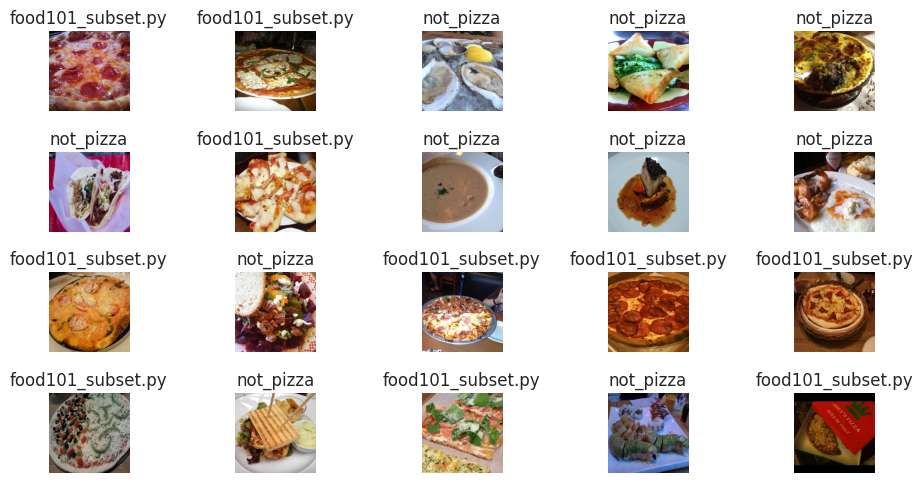

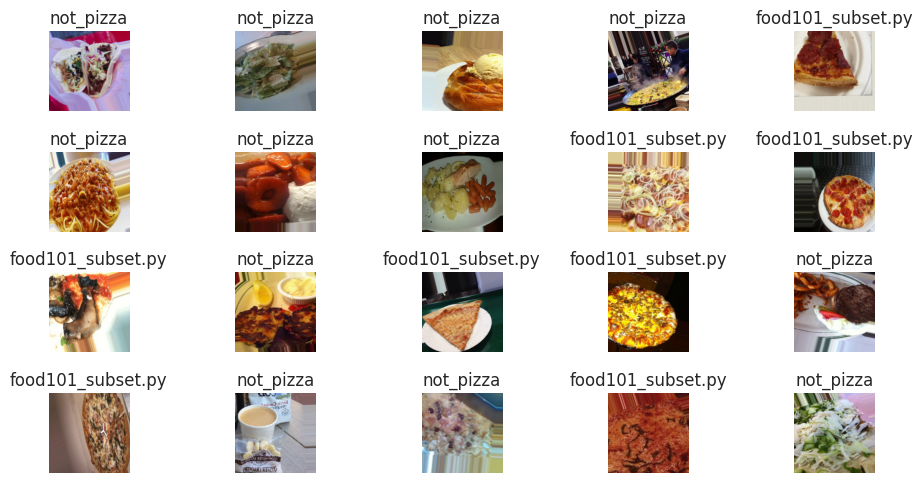

In [19]:
plot_random_images()
print('==================================================================================================')
plot_random_images_augmented()

In [20]:
model_3 = Sequential([
    Input(shape = (224, 224, 3)),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')
    ])

model_3.compile(
    loss = BinaryCrossentropy(),
    optimizer = Adam(),
    metrics = ['accuracy'])

history_3 = model_3.fit(
    train_data_augmented, # changing the training data
    epochs= 5,
    steps_per_epoch = len(train_data_augmented),
    validation_data = val_data,
    validation_steps = len(val_data))

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 295ms/step - accuracy: 0.5521 - loss: 0.7440 - val_accuracy: 0.6658 - val_loss: 0.6516
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.6385 - loss: 0.6344 - val_accuracy: 0.6276 - val_loss: 0.6679
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - accuracy: 0.6347 - loss: 0.6413 - val_accuracy: 0.6939 - val_loss: 0.6027
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 274ms/step - accuracy: 0.6703 - loss: 0.6108 - val_accuracy: 0.7092 - val_loss: 0.5866
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 262ms/step - accuracy: 0.6842 - loss: 0.5959 - val_accuracy: 0.7296 - val_loss: 0.5872


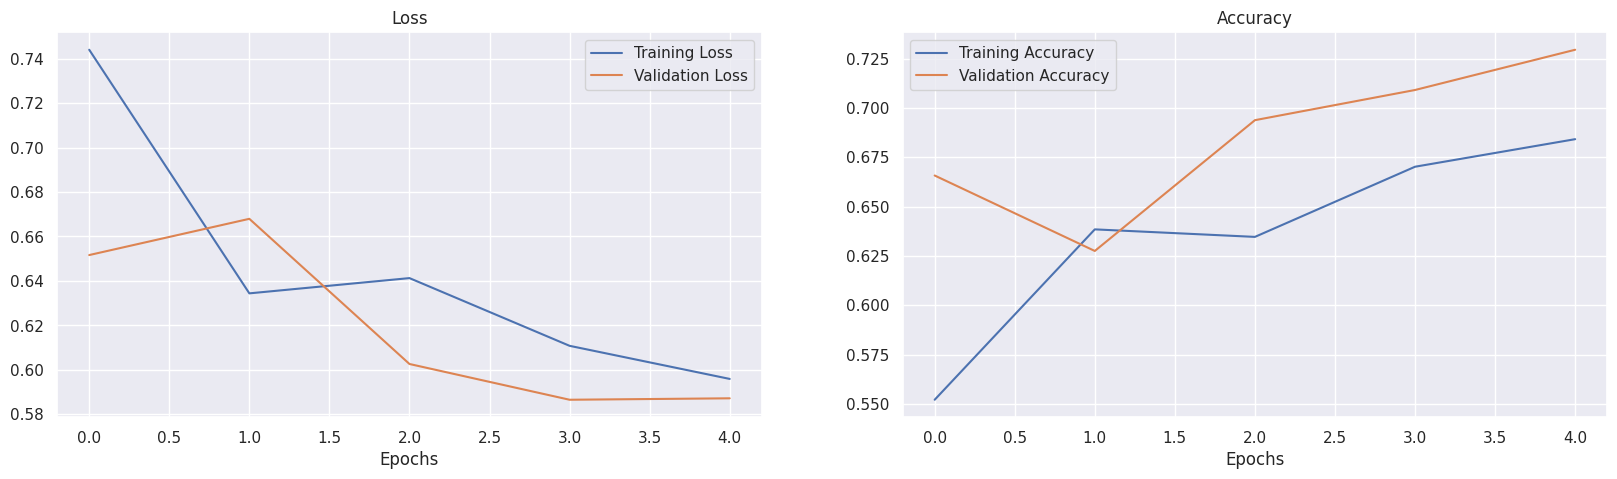

In [21]:
plot_loss_curves(history_3)

We did reach a maximum accuracy of above 70%, we can certainly make some more changes and try to improve the
accuracy further

### 7. Improving the model

There are lot of things we can change for improving the model such as:
1. Increasing the number of epochs
2. Adding more convolutional layers
3. Changing the number of filters
4. Changing the size of our filters
5. Changing the pool size of Max Pooling layer


In [22]:
model_4 = Sequential([
    Input(shape = (224, 224, 3)),
    Conv2D(filters = 10, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 64, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')
])

model_4.compile(
    loss = BinaryCrossentropy(),
    optimizer = Adam(learning_rate = 0.0001),
    metrics = ['accuracy'])

history_4 = model_4.fit(
    train_data, # Using non-augmented data
    epochs= 20,
    steps_per_epoch = len(train_data),
    validation_data = val_data,
    validation_steps = len(val_data))


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.5597 - loss: 0.6856 - val_accuracy: 0.5383 - val_loss: 0.6797
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5737 - loss: 0.6689 - val_accuracy: 0.5255 - val_loss: 0.6767
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6563 - loss: 0.6419 - val_accuracy: 0.7117 - val_loss: 0.6236
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.7338 - loss: 0.6022 - val_accuracy: 0.7474 - val_loss: 0.5869
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7332 - loss: 0.5722 - val_accuracy: 0.6531 - val_loss: 0.6013
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.7490 - loss: 0.5458 - val_accuracy: 0.7296 - val_loss: 0.5451
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7834 - loss: 0.5169 - val_accuracy: 0.7245 - val_loss: 0.5471
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7713 - loss: 0.5061 - val_accuracy: 0.7653 -

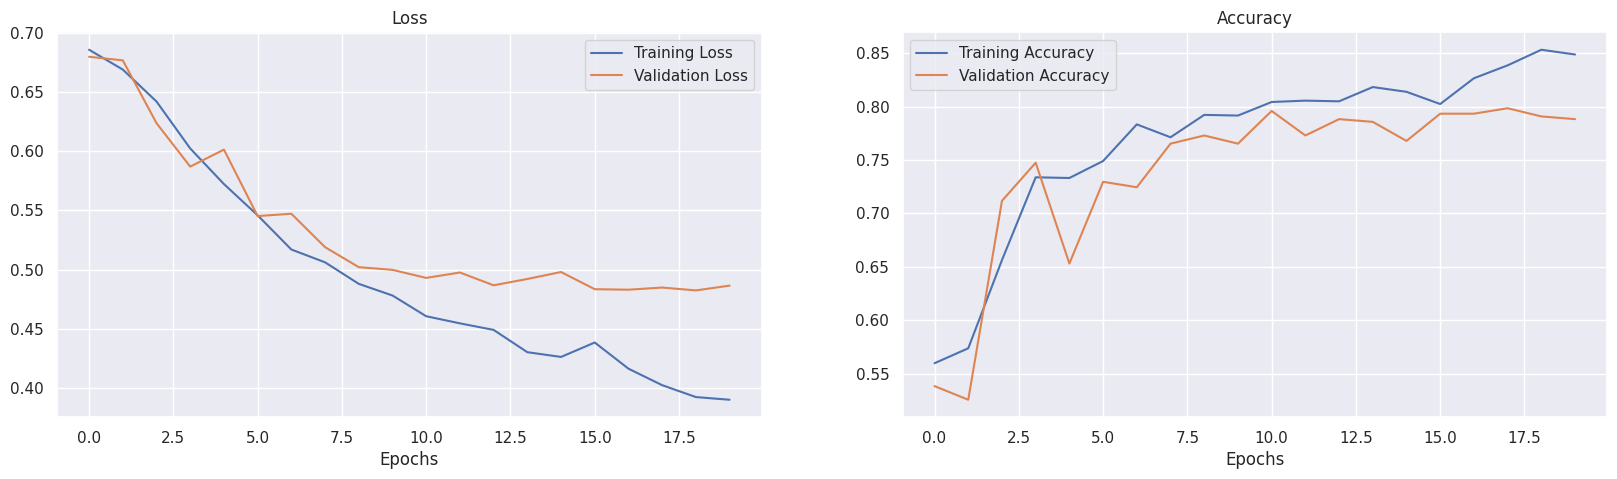

In [23]:
plot_loss_curves(history_4)

So we did managed to improve our accuracy to around 80%, which I think is not that bad considering the amount of
images we had.

### 8. Transfer Learning

In [24]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

#EfficientNet langsung
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

base_model.trainable = False

# Model
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_5 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20


E0000 00:00:1776065801.355195   16511 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.4898 - loss: 0.7475 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 168ms/step - accuracy: 0.5000 - loss: 0.7248 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.5133 - loss: 0.7249 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.5133 - loss: 0.7307 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.4981 - loss: 0.7226 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.5178 - loss: 0.7190 - val_accuracy: 0.5051 - val_loss: 0.6929
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.5133 - loss: 0.7090 - val_accuracy: 0.5051 - val_loss: 0.6928
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 0.5318 - loss: 0.7052 - val_accuracy: 0.4974 - val

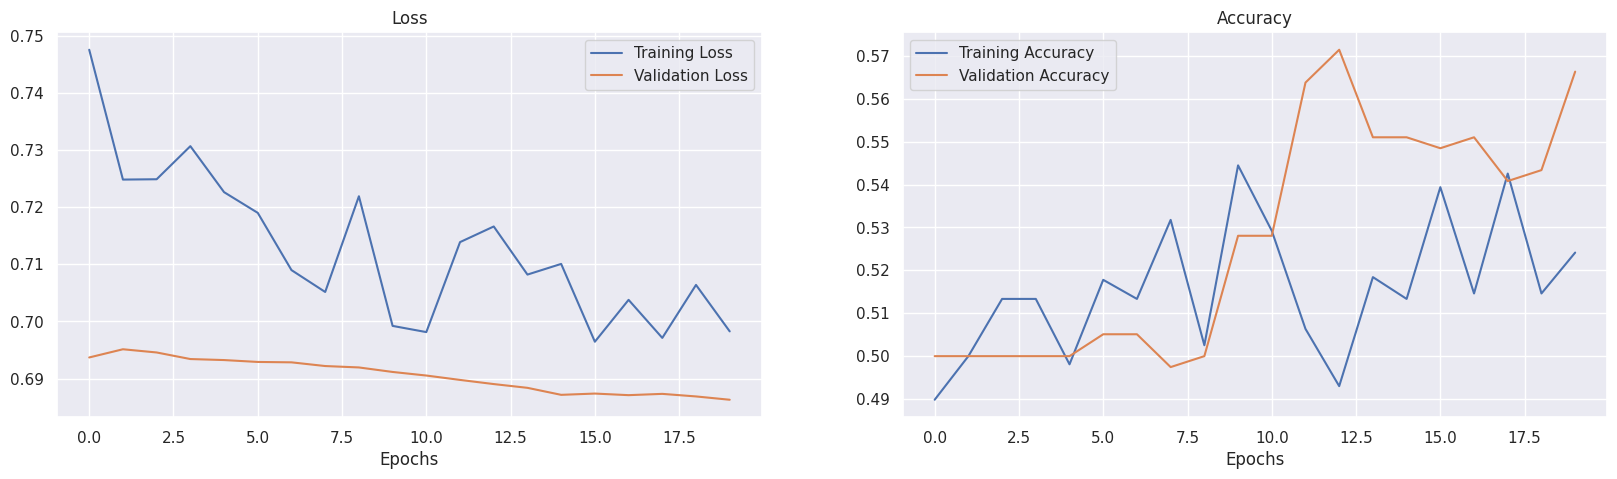

In [25]:
plot_loss_curves(history_5)